# Stored restriction maps visualisations

## 1. Import an Functions

In [54]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats
from tkinter import font
import scipy.sparse as sp

In [55]:
def fbc(L):
    l=L.shape[0]
    B=L.copy()
    for i in range(l):
        B[i,i]=np.sum(np.abs(L[i,:]))-np.abs(L[i,i])

    F=L-B
    return B , F

In [56]:
def matrix_abs(A):
    """
    Matrix absolute value: |A| = U Σ U^T, where A = U Σ V^T is the SVD.
    """
    U, S, Vt = np.linalg.svd(A)
    return U @ np.diag(S) @ U.T


def fbc_block(L, n, d):
    """
    Forman-Bochner decomposition for a block sheaf Laplacian (dense).
    Only suitable for small n — requires the full (n*d)x(n*d) matrix in RAM.
    """
    B = L.copy()
    for u in range(n):
        row_sum = np.zeros((d, d))
        for w in range(n):
            if w == u:
                continue
            block = L[u*d:(u+1)*d, w*d:(w+1)*d]
            if np.any(block != 0):
                row_sum += matrix_abs(block)
        B[u*d:(u+1)*d, u*d:(u+1)*d] = row_sum
    F = L - B
    return B, F


def compute_F_diags_from_coo(lap, n, d):
    """
    Compute F_{u,u} diagonal blocks of the Forman-Bochner decomposition
    directly from the COO-format sheaf Laplacian — no dense matrix needed.

    Background
    ----------
    The Forman-Bochner decomposition splits the sheaf Laplacian L into:
        L = B + F
    where B captures the "boundary" part (off-diagonal blocks unchanged,
    diagonal replaced by the sum of matrix-abs of neighbours) and F is the
    "curvature" remainder. Concretely, for each node u:

        B_{u,u} = sum_{v ~ u}  |L_{u,v}|       (matrix absolute value)
        F_{u,u} = L_{u,u}  -  B_{u,u}

    The eigenvalues of F_{u,u} are the per-node curvature scalars we care
    about. Crucially we only need these diagonal d×d blocks — the rest of
    F is never used — so we can skip building the full (n*d)×(n*d) matrix.

    Memory cost: O(E * d^2) vs O(n^2 * d^2) for the dense version.
    For roman_empire (n=22662, d=2) this means ~MB instead of ~15 GB.

    Parameters
    ----------
    lap : list/tuple of 3 tensors [row_indices, col_indices, values]
          COO representation of the (n*d) × (n*d) sheaf Laplacian,
          as saved by the training code.
    n   : number of graph nodes
    d   : stalk dimension (size of each block)

    Returns
    -------
    F_diags : np.ndarray of shape (n, d, d)
              F_{u,u} for every node u.
    """
    row_idx = lap[0].long().numpy().astype(np.int64)
    col_idx = lap[1].long().numpy().astype(np.int64)
    values  = lap[2].numpy()

    # The COO entries live in "scalar index" space (size n*d).
    # Convert each scalar index to (block_index, within-block offset):
    #   row i  →  block_row = i // d,  local_r = i % d
    # so the entry (row_idx[k], col_idx[k]) belongs to block (block_row[k], block_col[k])
    # at local position (local_r[k], local_c[k]) inside that d×d block.
    block_row = row_idx // d
    block_col = col_idx // d
    local_r   = row_idx % d
    local_c   = col_idx % d

    # Diagonal blocks are those where the block row equals the block column (u == v).
    is_diag = (block_row == block_col)

    # --- Step 1: collect diagonal blocks L_{u,u} ---
    # Scatter the COO values that belong to diagonal blocks into a (n, d, d) array.
    # np.add.at handles duplicate (u, r, c) indices correctly (accumulates).
    diag_blocks = np.zeros((n, d, d))
    dm = is_diag
    np.add.at(diag_blocks, (block_row[dm], local_r[dm], local_c[dm]), values[dm])

    # --- Step 2: group off-diagonal COO entries by their (u, v) block pair ---
    # We need one d×d matrix per (u,v) edge so we can apply matrix_abs to it.
    off_mask = ~is_diag
    off_br   = block_row[off_mask]   # source block (node u)
    off_bc   = block_col[off_mask]   # target block (node v)
    off_lr   = local_r[off_mask]     # row offset inside the d×d block
    off_lc   = local_c[off_mask]     # col offset inside the d×d block
    off_vals = values[off_mask]

    # Encode each (u, v) pair as a single integer so np.unique can find groups.
    # Since v < n always, the map  id = u*n + v  is injective.
    block_ids = off_br * n + off_bc
    unique_ids, inverse = np.unique(block_ids, return_inverse=True)
    # unique_ids : one entry per distinct (u,v) edge direction  (shape: num_blocks,)
    # inverse    : maps each COO entry back to its group index    (shape: len(off_vals),)
    num_blocks = len(unique_ids)

    # Scatter all off-diagonal scalar values into their respective d×d blocks.
    # After this, all_blocks[k] = L_{u_k, v_k}  for the k-th unique (u,v) pair.
    all_blocks = np.zeros((num_blocks, d, d))
    np.add.at(all_blocks, (inverse, off_lr, off_lc), off_vals)

    # --- Step 3: compute matrix_abs for all off-diagonal blocks in one batch SVD ---
    # matrix_abs(A) = U @ diag(S) @ U^T   (uses left singular vectors, not right)
    # We skip exact-zero blocks (isolated nodes / missing edges) to avoid SVD of zeros.
    nonzero_mask = np.any(all_blocks != 0, axis=(1, 2))
    abs_blocks = np.zeros_like(all_blocks)
    if np.any(nonzero_mask):
        nz = all_blocks[nonzero_mask]
        U, S, _ = np.linalg.svd(nz)                               # batch SVD
        # einsum: result[b,i,k] = sum_j  U[b,i,j] * S[b,j] * U[b,k,j]
        #                        = (U @ diag(S) @ U^T)[b]
        abs_blocks[nonzero_mask] = np.einsum('bij,bj,bkj->bik', U, S, U)

    # --- Step 4: accumulate B_{u,u} = sum_{v~u} |L_{u,v}| for every node u ---
    # Recover the source node u from the unique block id: u = id // n.
    B_diag = np.zeros((n, d, d))
    unique_block_rows = (unique_ids // n).astype(np.int64)
    # np.add.at accumulates all blocks that share the same source node u.
    np.add.at(B_diag, unique_block_rows, abs_blocks)

    # --- Step 5: F_{u,u} = L_{u,u} - B_{u,u} ---
    return diag_blocks - B_diag


## 2. Data Manipulation: Load Laplacian and compute curvatures 

In [ ]:
# Load maps and Laplacians
stalk_dim = 2
hidden_channels = 16
dataset = "cora"
layers = 2
epochs = 500
mode = "Bundle"
#num_nodes = 22662 # Roman Empire
#num_nodes = 10000 # minsesweeper
#num_nodes = 3327 # Citeseer 
num_nodes = 2708 # Cora

#MAPS = []
LAPLACIANS = []
for layer in range(layers):
    #map_path = f"../results/maps/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/{mode}Sheaf_{dataset}_layer{layer}_fold3_seed43.pt"
    lap_path = f"../results/laplacians/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/{mode}Sheaf_{dataset}_layer{layer}_fold3_seed43.pt"
    #MAPS.append(torch.load(map_path))
    LAPLACIANS.append(torch.load(lap_path))

# Maps: shape [num_edges, 2 + d^2], first two cols are source/target
#d = stalk_dim
#map_cols = [f"a{i+1}{j+1}" for i in range(d) for j in range(d)]
#DF = []
#for maps_tensor in MAPS:
    #df = pd.DataFrame(maps_tensor[:, 2:].numpy(), columns=map_cols)
    #df.insert(0, "source", maps_tensor[:, 0].long().numpy())
    #df.insert(1, "target", maps_tensor[:, 1].long().numpy())
    #DF.append(df)


C:\Users\Utente\AppData\Local\Temp\ipykernel_7208\3111878778.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  LAPLACIANS.append(torch.load(lap_path))


In [59]:
n, d = num_nodes, stalk_dim

F_diag_list = []   # list of [n, d, d] arrays — one d×d block per node per layer

for lap in LAPLACIANS:
    # Compute F diagonal blocks directly from COO — never builds the dense matrix
    F_diags = compute_F_diags_from_coo(lap, n, d)   # shape [n, d, d]
    F_diag_list.append(F_diags)

curv_eigs = [np.linalg.eigvalsh(F_diag_list[layer]) for layer in range(layers)]  # [layers][n, d]


In [60]:
from scipy.sparse.linalg import eigsh

lap = LAPLACIANS[0]
row_idx = lap[0].long().numpy()
col_idx = lap[1].long().numpy()

# Decode nd-space indices back to node numbers
edges = set()
for r, c in zip(row_idx, col_idx):
    u, v = int(r) // d, int(c) // d
    if u != v:
        edges.add((min(u, v), max(u, v)))

G = nx.Graph()
G.add_nodes_from(range(n))
G.add_edges_from(sorted(edges))
nodelist = list(range(n))
print(G.number_of_nodes(), G.number_of_edges())

# Keep the topological Laplacian sparse throughout
L_top_un = nx.laplacian_matrix(G, nodelist=nodelist).astype(float)   # sparse
degrees  = np.array(L_top_un.diagonal())
d0       = degrees + 1
D_inv_sqrt = sp.diags(1.0 / np.sqrt(d0))
L_top_sp = D_inv_sqrt @ L_top_un @ D_inv_sqrt   # sparse normalized Laplacian

# Scalar Forman curvature: f0[u] = 2*L[u,u] - sum_j |L[u,j]|
diag_vals    = np.array(L_top_sp.diagonal())
abs_row_sums = np.array(np.abs(L_top_sp).sum(axis=1)).ravel()
f0_top       = 2 * diag_vals - abs_row_sums

# Partial eigendecomposition (k smallest non-trivial) — avoids dense eigh
#k_eigs = min(200, n - 2)
#e_top, ev_top = eigsh(L_top_sp, k=k_eigs, which='SM')
#e_top = np.sort(e_top)


2708 5278


## 3. Visualizations: Plot of curvatures, and then spectral quantities 

2708 2708 2708


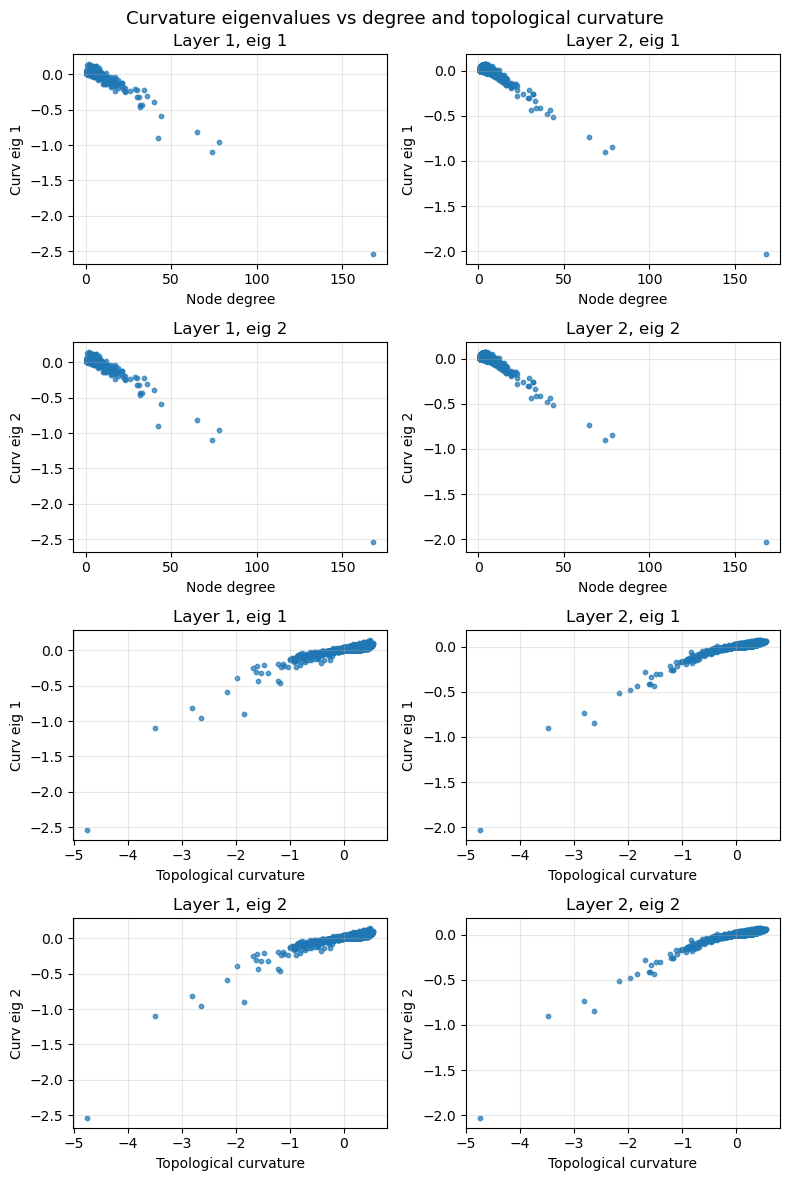

In [61]:
node_degrees = np.array([G.degree(u) for u in nodelist])
print(len(node_degrees), len(f0_top), len(curv_eigs[0][:,0]))
fig, axes = plt.subplots(2*d, layers, figsize=(4*layers, 3*2*d))
if layers == 1: axes = axes.reshape(-1, 1)

for k in range(d):
    for layer in range(layers):
        axes[k, layer].scatter(node_degrees, curv_eigs[layer][:, k], s=10, alpha=0.7)
        axes[k, layer].set_xlabel("Node degree")
        axes[k, layer].set_ylabel(f"Curv eig {k+1}")
        axes[k, layer].set_title(f"Layer {layer+1}, eig {k+1}")
        axes[k, layer].grid(alpha=0.3)

        axes[d+k, layer].scatter(f0_top, curv_eigs[layer][:, k], s=10, alpha=0.7)
        axes[d+k, layer].set_xlabel("Topological curvature")
        axes[d+k, layer].set_ylabel(f"Curv eig {k+1}")
        axes[d+k, layer].set_title(f"Layer {layer+1}, eig {k+1}")
        axes[d+k, layer].grid(alpha=0.3)

fig.suptitle("Curvature eigenvalues vs degree and topological curvature", fontsize=13)
fig.tight_layout()
#fig.savefig(f"../results/images/{dataset}_curv_scatter.pdf")


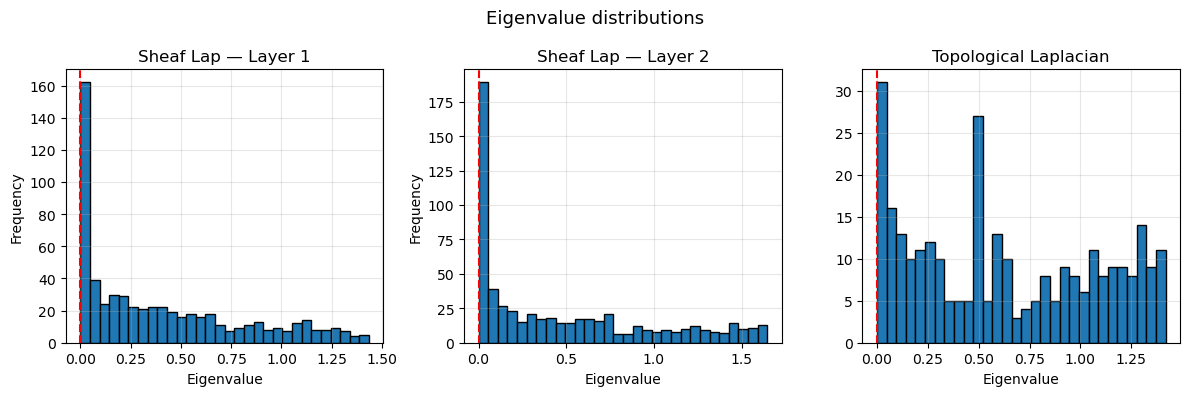

In [ ]:
fig, axes = plt.subplots(1, layers+1, figsize=(4*(layers+1), 4))
for layer in range(layers):
    axes[layer].hist(e_list[layer], bins=30, edgecolor="black")
    axes[layer].axvline(0, color="red", linestyle="--")
    axes[layer].set_title(f"Sheaf Lap — Layer {layer+1}")
    axes[layer].set_xlabel("Eigenvalue")
    axes[layer].set_ylabel("Frequency")
    axes[layer].grid(alpha=0.3)
axes[layers].hist(e_top, bins=30, edgecolor="black")
axes[layers].axvline(0, color="red", linestyle="--")
axes[layers].set_title("Topological Laplacian")
axes[layers].set_xlabel("Eigenvalue")
axes[layers].grid(alpha=0.3)
fig.suptitle("Eigenvalue distributions", fontsize=13)
fig.tight_layout()
#fig.savefig(f"../results/images/{dataset}_eigenvalue_distributions.pdf")


## 4. Plotting of the Graphs

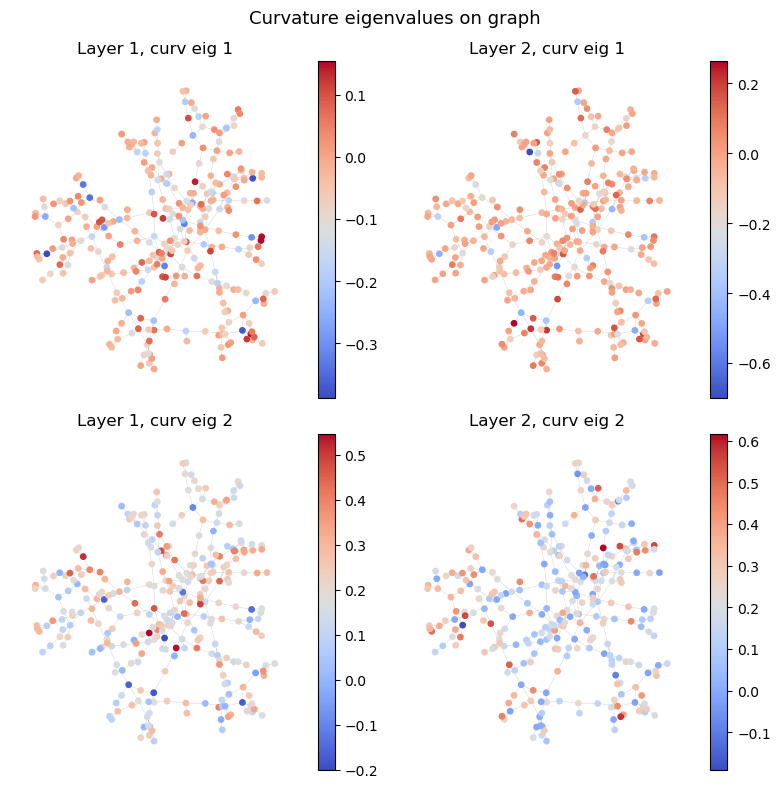

In [102]:
pos_use = nx.spring_layout(G, seed=42)
cmap = plt.cm.coolwarm

fig, axes = plt.subplots(d, layers, figsize=(4*layers, 4*d))
if d == 1: axes = axes.reshape(1, -1)
if layers == 1: axes = axes.reshape(-1, 1)

for k in range(d):
    for layer in range(layers):
        ax = axes[k, layer]
        vals = curv_eigs[layer][:, k]
        norm = plt.Normalize(vmin=vals.min(), vmax=vals.max())
        nx.draw_networkx_nodes(G, pos_use, ax=ax, nodelist=nodelist, node_size=15, node_color=cmap(norm(vals)))
        nx.draw_networkx_edges(G, pos_use, ax=ax, width=0.3, alpha=0.2)
        plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)
        ax.set_title(f"Layer {layer+1}, curv eig {k+1}")
        ax.axis("off")

fig.suptitle("Curvature eigenvalues on graph", fontsize=13)
fig.tight_layout()
#fig.savefig(f"../results/images/{dataset}_curv_graph.pdf")
